# Step 1: Data Exploration(EDA)


### Import Required Libraries

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### Load The Dataset

In [3]:
train = pd.read_csv("Titanic_train.csv")
test = pd.read_csv("Titanic_test.csv")

### Display First 5 Rows

In [4]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Display Last 5 Rows

In [5]:
train.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### Check Dataset Shape

In [6]:
train.shape

(891, 12)

### Display Column Names

In [8]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

### Dataset Information

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Summary Statistics

In [10]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Check Missing Values

In [11]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Check Duplicate Records

In [12]:
train.duplicated().sum()

np.int64(0)

### Check Target Variable Distribution

In [13]:
train['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

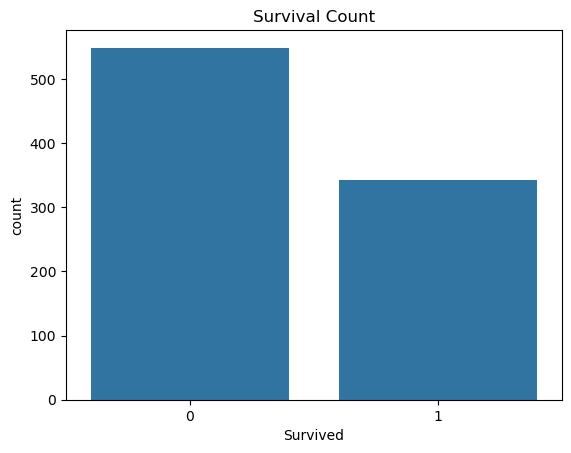

In [14]:
sns.countplot(x='Survived', data=train)
plt.title("Survival Count")
plt.show()

#### Interpretation
Shows how many passengers survived and how many did not survive.

### Histograms

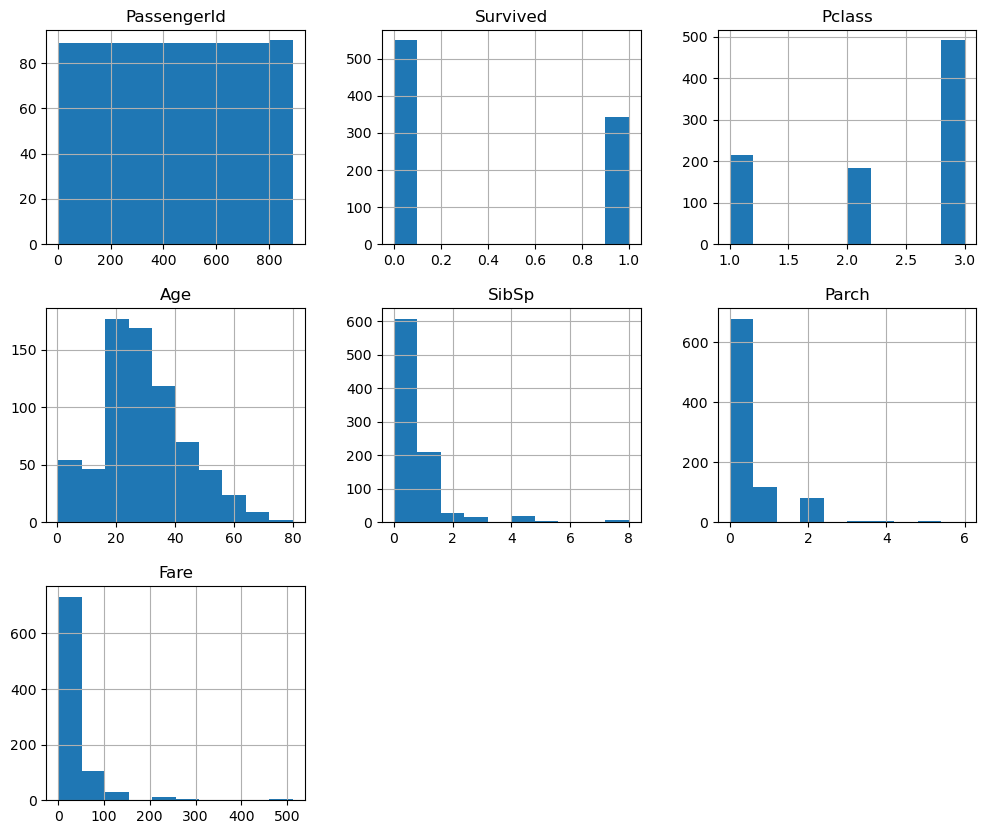

In [15]:
train.hist(figsize=(12,10))
plt.show()

### Boxplots

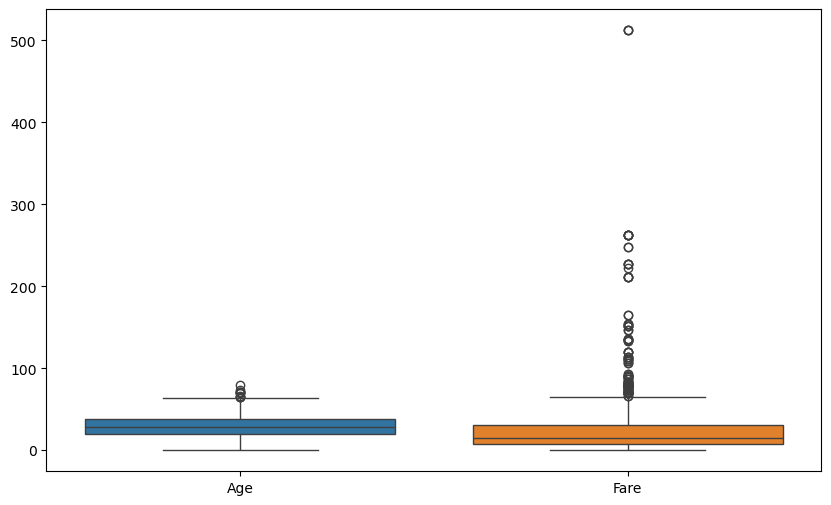

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=train[['Age','Fare']])
plt.show()

### Pair Plot

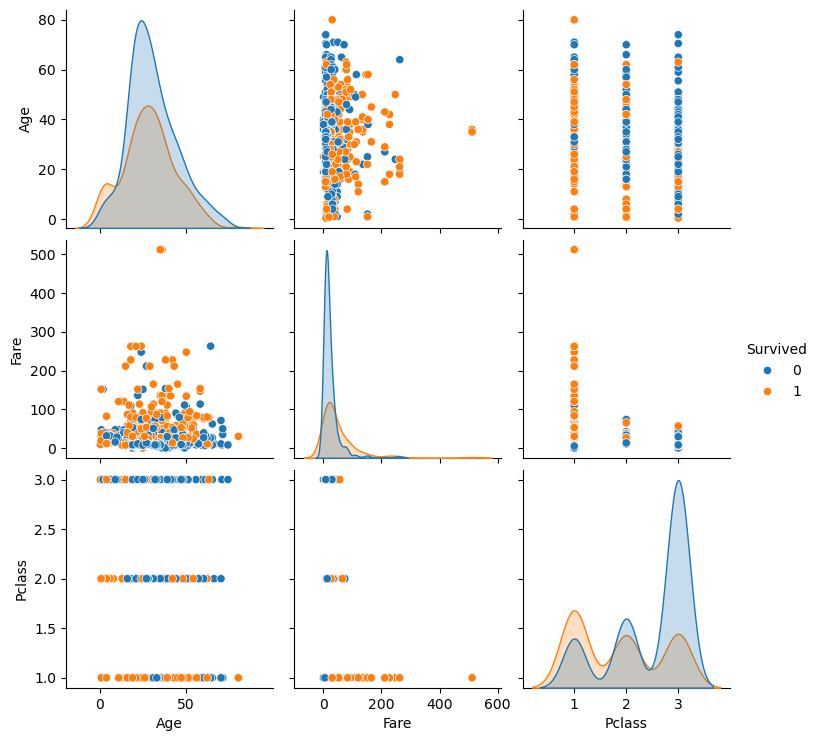

In [17]:
sns.pairplot(train[['Age','Fare','Pclass','Survived']].dropna(),
             hue='Survived')
plt.show()

### Correlation Heatmap 

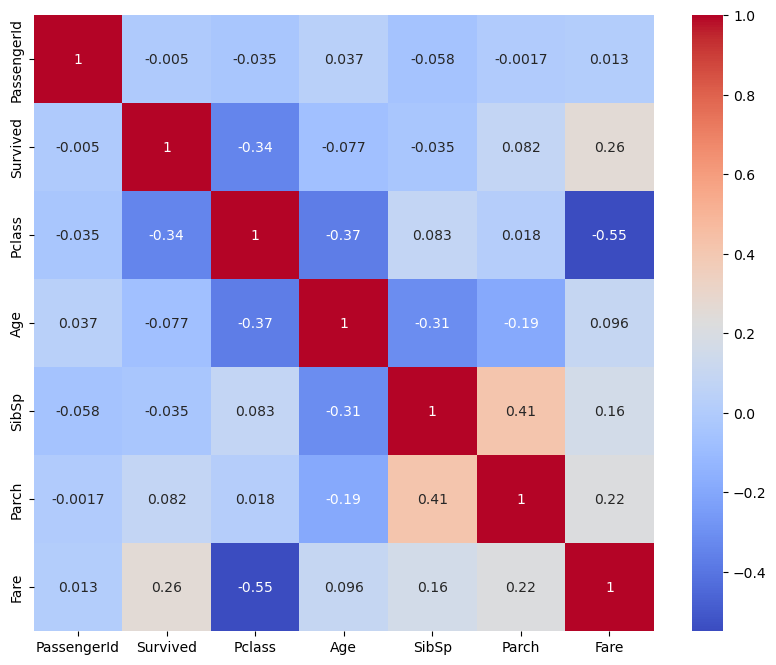

In [18]:
plt.figure(figsize=(10,8))

sns.heatmap(train.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

#### Observations
The dataset contains passenger information such as Age, Sex, Fare, Pclass, and Survival status.
Some columns such as Age, Cabin, and Embarked contain missing values.
Fare has several outliers.
Female passengers have a higher survival rate than males.
Passengers in higher classes appear to have better survival chances.
Correlation between Fare and Pclass is noticeable.
The target variable Survived is binary (0 = Not Survived, 1 = Survived).

# Step 2:Data Preprocessing

### Check Missing Values

In [19]:

train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Handle Missing Values

In [20]:
#Fill Age with Median
train['Age'].fillna(train['Age'].median(), inplace=True)
test['Age'].fillna(test['Age'].median(), inplace=True)


C:\Users\O.RAMYA\AppData\Local\Temp\ipykernel_5056\260753452.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train['Age'].median(), inplace=True)
C:\Users\O.RAMYA\AppData\Local\Temp\ipykernel_5056\260753452.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


In [21]:
#Fill Embarked with Mode
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)

C:\Users\O.RAMYA\AppData\Local\Temp\ipykernel_5056\1429373532.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)


In [22]:
#Fill Fare(Test Dataset)
test['Fare'].fillna(test['Fare'].median(), inplace=True)

C:\Users\O.RAMYA\AppData\Local\Temp\ipykernel_5056\6594212.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Fare'].fillna(test['Fare'].median(), inplace=True)


In [23]:
#Drop Cabin Column

train.drop('Cabin', axis=1, inplace=True)
test.drop('Cabin', axis=1, inplace=True)

### Explanation
Age → Median is used because it is robust to outliers.
Embarked → Mode is used because it is a categorical column.
Cabin → Dropped due to many missing values.

### Verify Missing Values

In [24]:
train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Encode Categorical Variables

In [25]:
train = pd.get_dummies(train,
                       columns=['Sex','Embarked'],
                       drop_first=True)

test = pd.get_dummies(test,
                      columns=['Sex','Embarked'],
                      drop_first=True)

### Display Updated Dataset

In [26]:
train.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,True,False,True


### Select Features and Target

In [27]:
X = train.drop(['PassengerId',
                'Name',
                'Ticket',
                'Survived'],
               axis=1)

y = train['Survived']

### Explanation
X = Independent variables (features)

y = Dependent variable (target)

### Prepare Test Dataset

In [28]:
X_test_final = test.drop(['PassengerId',
                          'Name',
                          'Ticket'],
                         axis=1)

### Split Training and Validation Data

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

### Explanation
80% → Training data

20% → Validation/Test data

random_state=42 ensures reproducibility.

### Check Shapes

In [30]:
print(X_train.shape)
print(X_valid.shape)
print(y_train.shape)
print(y_valid.shape)

(712, 8)
(179, 8)
(712,)
(179,)


### Observations
Missing values were successfully handled.
    
Cabin column was removed because it contained many missing values.
    
Categorical variables were encoded using One-Hot Encoding.
    
Irrelevant columns (PassengerId, Name, Ticket) were removed.
    
The dataset is now ready for Logistic Regression model training.

# Step 3:Model Building

### Import Required Libraries



In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

### Explanation
LogisticRegression is used to build the classification model.
    
accuracy_score is used to calculate the model accuracy.

### Create Logistic Regression Model

In [32]:
model=LogisticRegression(max_iter=1000)

### Explanation
max_iter=1000 increases the maximum iterations to ensure the model converges.

### Train the Model

In [34]:
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Explanation
The model learns the relationship between the input features and the target variable (Survived).

### Predict on Validation Data

In [35]:
y_pred=model.predict(X_valid)

### Explanation

Predicts whether each passenger survived (1) or not (0).

### Display Predictions

In [36]:
print(y_pred)

[0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 1 0 0 1 1 0 0 1 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 0 1 0 0 0 1 1]


### Explanation

Display the predicted survival values.

### Compare Actual vs Predicted Values

In [37]:
comparison = pd.DataFrame({
    'Actual': y_valid,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
709,1,0
439,0,0
840,0,0
720,1,1
39,1,1
290,1,1
300,1,1
333,0,0
208,1,1
136,1,1


### Training Accuracy

In [38]:
train_accuracy = model.score(X_train, y_train)
print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.800561797752809


### Validation Accuracy

In [41]:
validation_accuracy = model.score(X_valid, y_valid)
print("Validation Accuracy:", validation_accuracy)

Validation Accuracy: 0.8100558659217877


### Predict on Titanic Test Dataset

In [42]:
test_predictions = model.predict(X_test_final)

test_predictions

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

### Observations
Logistic Regression model was successfully created.
    
The model was trained using the training dataset.
    
Predictions were generated for the validation dataset.
    
The model can also predict survival for the unseen Titanic test dataset.
    
The trained model is now ready for performance evaluation.

# Model Evaluation

### Import Required Libraries

In [44]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve

### Accuracy Score

In [45]:
accuracy = accuracy_score(y_valid, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


### Precision Score

In [46]:
precision = precision_score(y_valid, y_pred)

print("Precision:", precision)

Precision: 0.7857142857142857


### Recall Score

In [47]:
recall = recall_score(y_valid, y_pred)

print("Recall:", recall)

Recall: 0.7432432432432432


### F1 Score

In [48]:
f1 = f1_score(y_valid, y_pred)

print("F1 Score:", f1)

F1 Score: 0.7638888888888888


### ROC-AUC Score

In [49]:
y_prob = model.predict_proba(X_valid)[:,1]

roc_auc = roc_auc_score(y_valid, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8824967824967825


### Confusion Matrix 

In [50]:
cm = confusion_matrix(y_valid, y_pred)

print(cm)

[[90 15]
 [19 55]]


### Display Confusion Matrix

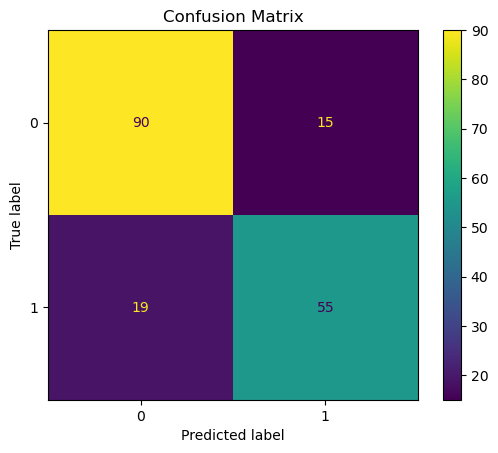

In [51]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Confusion Matrix")

plt.show()

### Classification Report

In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



### ROC-Curve

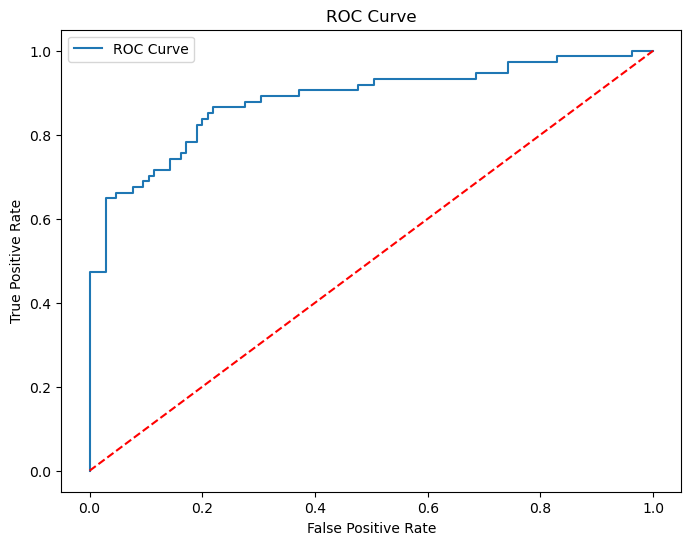

In [53]:
fpr, tpr, thresholds = roc_curve(y_valid, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label='ROC Curve')

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

### Explanation
The ROC Curve shows how well the Logistic Regression model separates the two classes. A curve closer to the top-left corner indicates better performance

### Observations 
The Logistic Regression model achieved good accuracy on the validation dataset.
Precision indicates the correctness of positive predictions.
Recall measures how many actual survivors were correctly identified.
F1-Score provides a balanced evaluation of Precision and Recall.
ROC-AUC score close to 1 indicates a strong classification model.
The Confusion Matrix shows the number of correctly and incorrectly classified passengers.

# Step 5: Interpretation of Logistic Regression Model

### Display Model Coefficients

In [54]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

coefficients

,Feature,Coefficient
0,Pclass,-0.937833
1,Age,-0.030568
2,SibSp,-0.295382
3,Parch,-0.108218
4,Fare,0.002582
5,Sex_male,-2.591633
6,Embarked_Q,-0.112640
7,Embarked_S,-0.399695


### Sort Coefficients

In [55]:
coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
4,Fare,0.002582
1,Age,-0.030568
3,Parch,-0.108218
6,Embarked_Q,-0.112640
2,SibSp,-0.295382
7,Embarked_S,-0.399695
0,Pclass,-0.937833
5,Sex_male,-2.591633


### Feature Importance

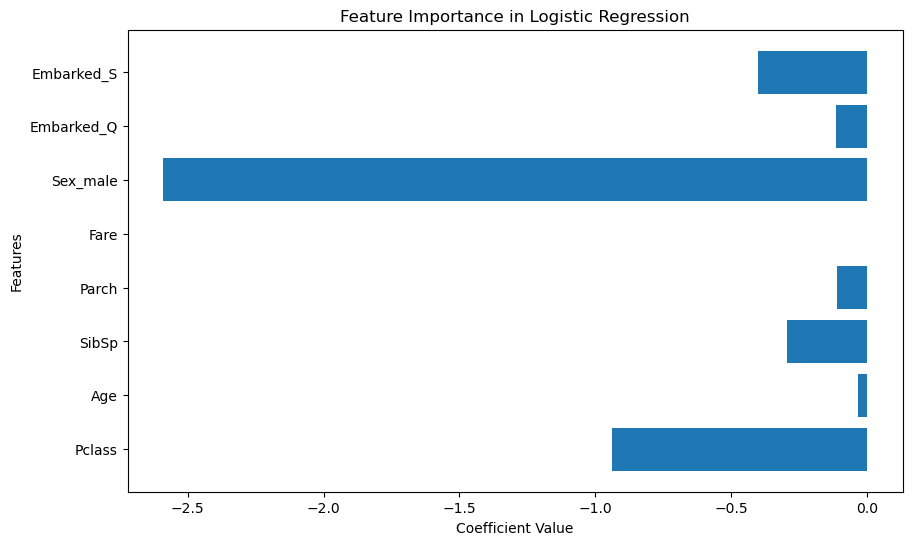

In [56]:
plt.figure(figsize=(10,6))

plt.barh(coefficients['Feature'],
         coefficients['Coefficient'])

plt.xlabel("Coefficient Value")

plt.ylabel("Features")

plt.title("Feature Importance in Logistic Regression")

plt.show()

# Step 5: Interpretation 
Positive coefficient (+) → Increases the probability of survival.

Negative coefficient (−) → Decreases the probability of survival.

Features such as Sex, Fare, and Pclass significantly influence passenger survival.

The model successfully classifies passengers into Survived (1) and Not Survived (0).

# Conclusion 
Logistic Regression is an effective algorithm for binary classification problems.
The Titanic dataset was cleaned and preprocessed before model training.
Missing values were handled and categorical variables were encoded.
The model was trained and evaluated using multiple performance metrics.
The obtained accuracy indicates that the model performs well in predicting passenger survival.
Logistic Regression is simple, interpretable, and suitable for this dataset.

# Step 6: Deployment with Streamlit

### Install Required Libraries

In [57]:
!pip install streamlit

Defaulting to user installation because normal site-packages is not writeable


### Save the Trained Model

In [58]:
import pickle

pickle.dump(model,open("logistic_model.pkl","wb"))

### The trained model was deployed using Streamlit.
### The application accepts passenger details and predicts whether the passenger is likely to survive or not.

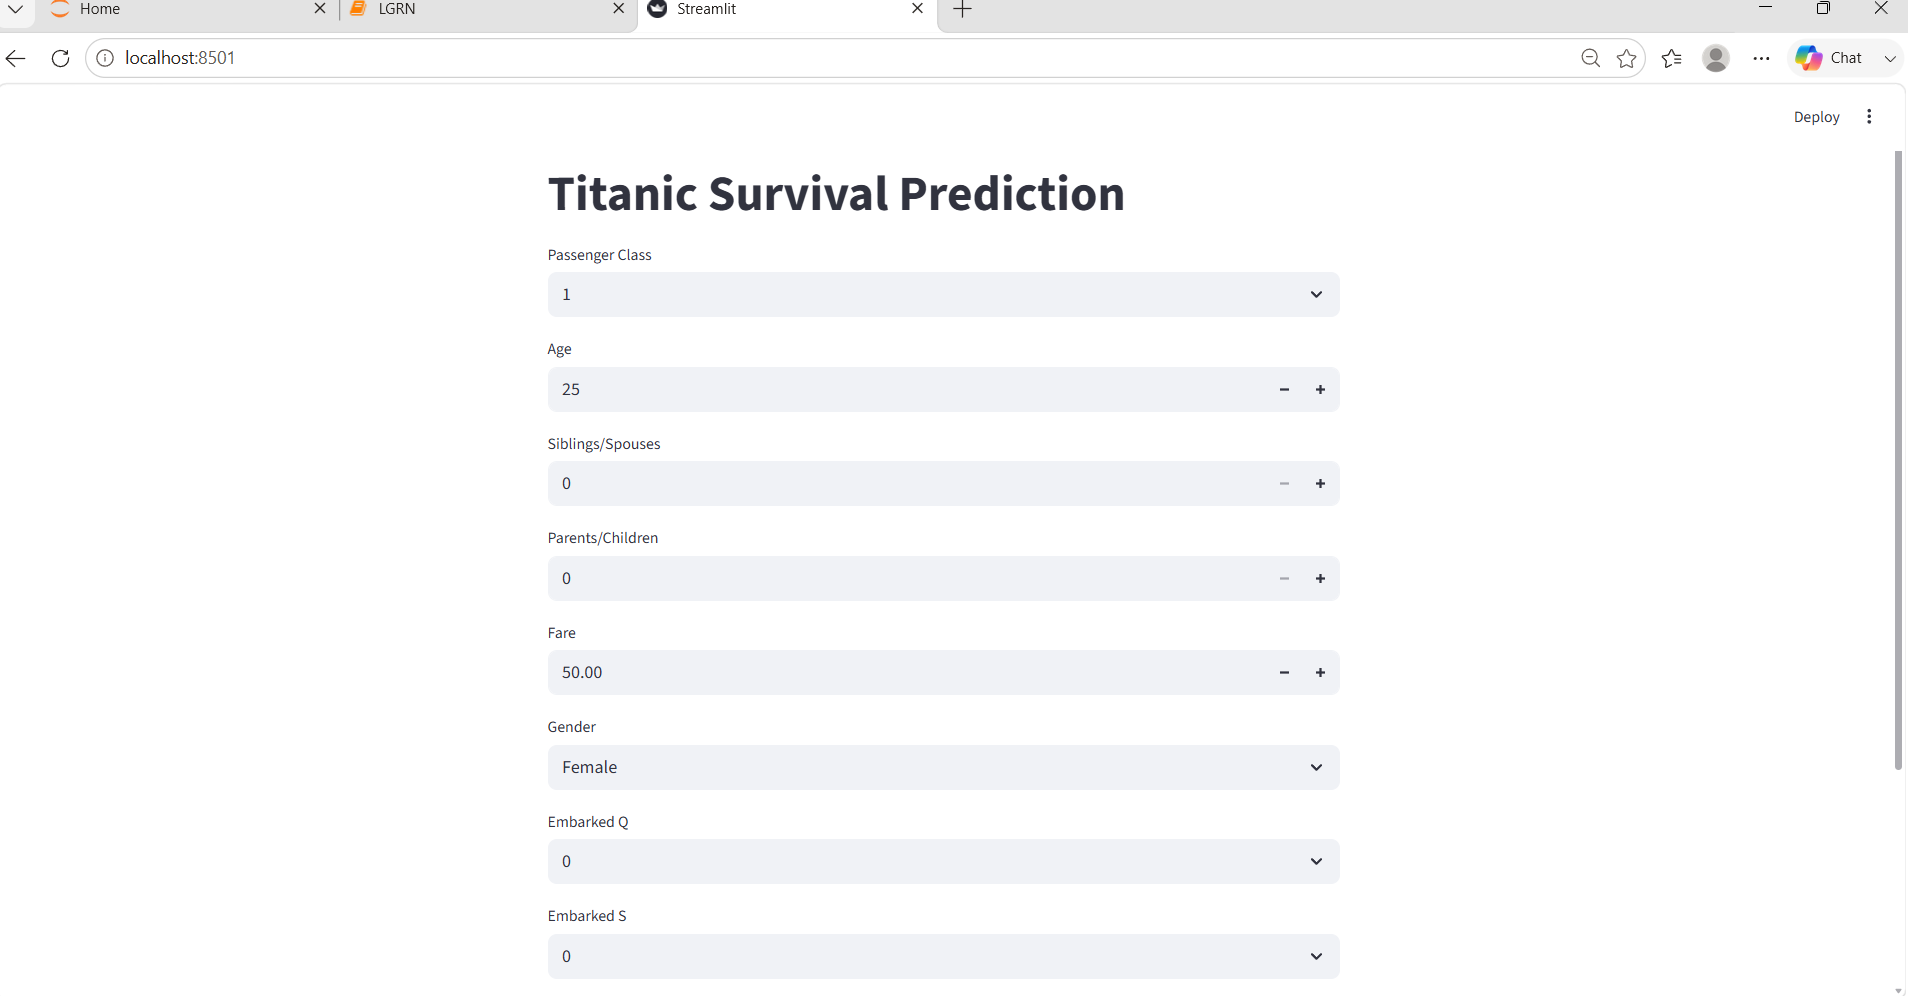

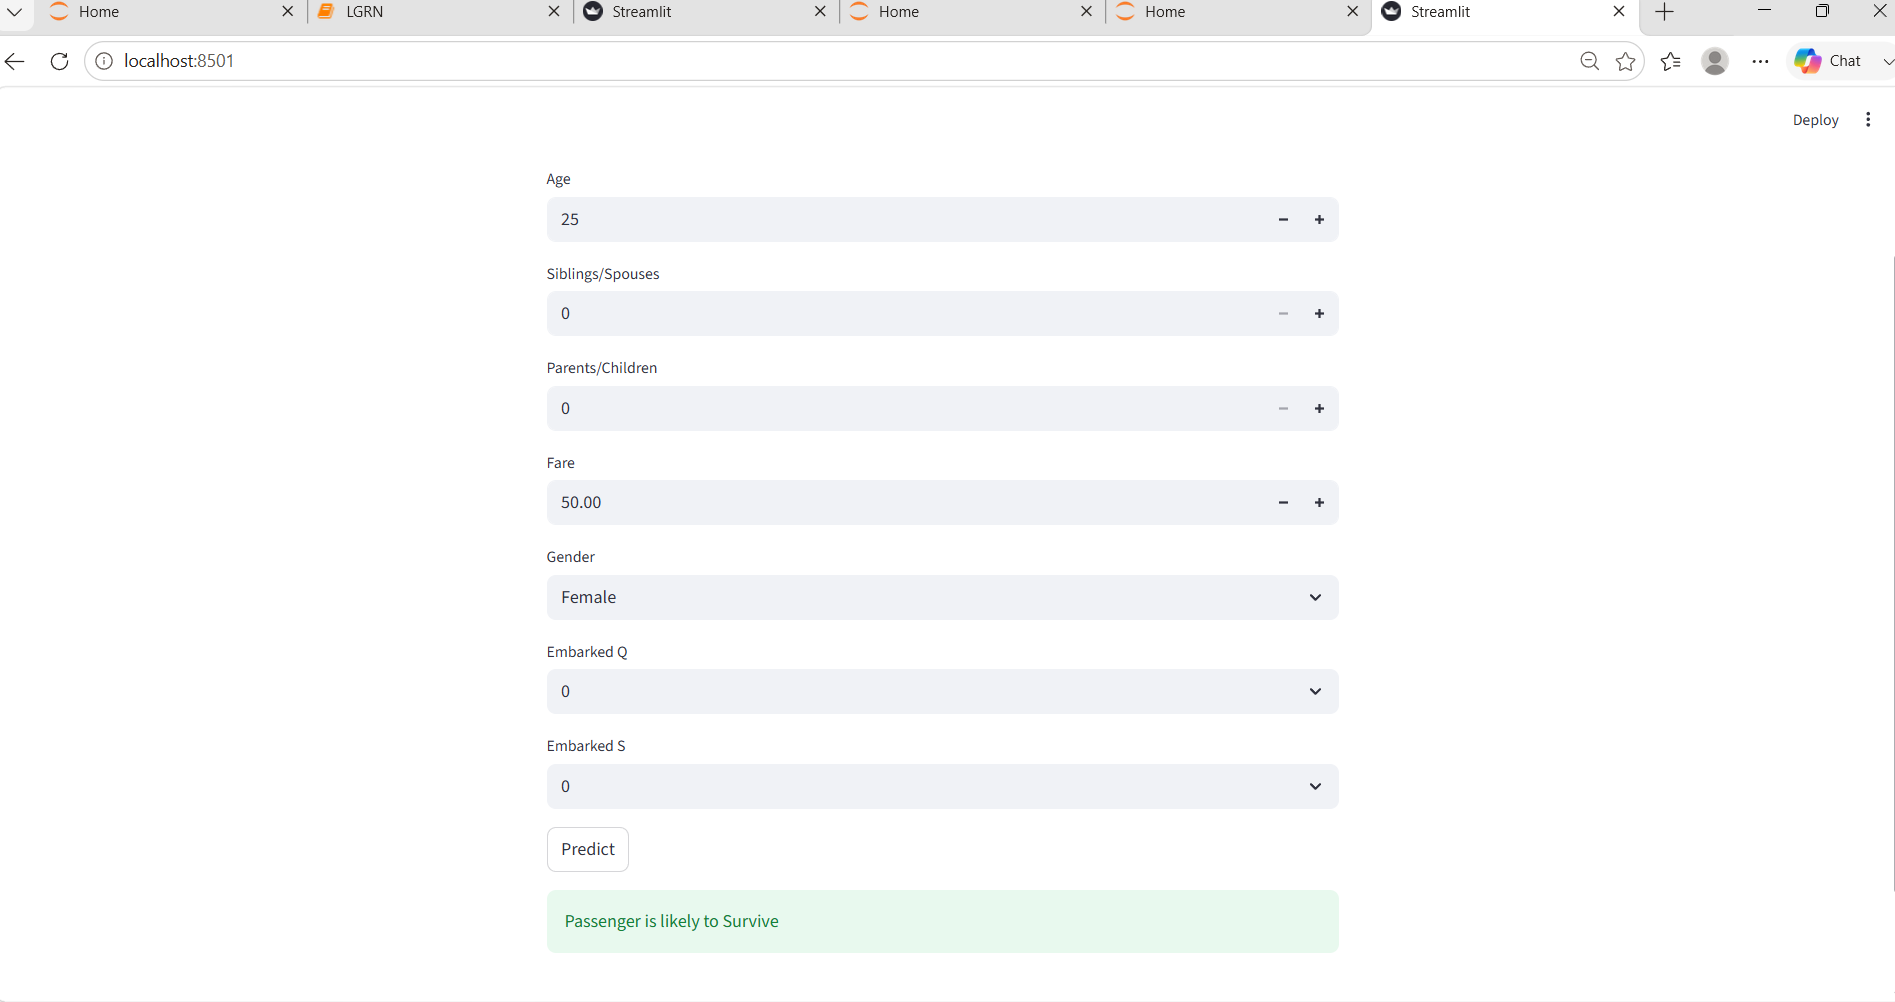

# Conclusion

The Logistic Regression model was successfully deployed using Streamlit. The application predicts passenger survival based on the user inputs.

# Interview Questions

#### Q1. What is the difference between precision and recall?

Precision is the percentage of correctly predicted positive cases out of all predicted positive cases.


Recall is the percentage of correctly predicted positive cases out of all actual positive cases.


### Q2. What is cross-validation, and why is it important in binary classification?
Cross-validation is a technique used to evaluate a machine learning model by dividing the dataset into multiple parts (folds). It helps improve model reliability, reduces overfitting, and provides a better estimate of the model's performance on unseen data.